## Setup

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

In [2]:
SEED = 42
np.random.seed(SEED)

EXPERIMENT_DIR = Path(__file__).parent if "__file__" in dir() else Path.cwd()
REPO_ROOT = EXPERIMENT_DIR.parent.parent
CONFIG_PATH = EXPERIMENT_DIR / "config.yaml"
METRICS_PATH = EXPERIMENT_DIR / "metrics.json"
FIGURES_DIR = EXPERIMENT_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

print(f"Experiment: {config['experiment']['id']} — {config['experiment']['name']}")
print(f"Repo root: {REPO_ROOT}")

Experiment: exp-002 — visual-lab-explore
Repo root: /Users/shreyaschitransh/code/eat-segmentation


In [3]:
DICOM_DIR = REPO_ROOT / config["data"]["dicom_dir"]
GT_FAT_DIR = REPO_ROOT / config["data"]["gt_fat_range_dir"]
GT_COMBINED_DIR = REPO_ROOT / config["data"]["gt_combined_range_dir"]
GT_HIGHER_DIR = REPO_ROOT / config["data"]["gt_higher_range_dir"]
FAT_IMAGES_DIR = REPO_ROOT / config["data"]["fat_images_dir"]

patients = sorted([p.name for p in DICOM_DIR.iterdir() if p.is_dir()])
print(f"Patients in DICOM dir: {len(patients)}")
print(patients)

Patients in DICOM dir: 20
['ACel', 'AEdu', 'AFre', 'AMar', 'AXav', 'CFer', 'CLis', 'DLag', 'DSan', 'DSil', 'EGra', 'FGas', 'FPiq', 'ISou', 'JFul', 'JMir', 'MPai', 'MSil', 'TJes', 'VMar']


## Data — DICOM Structure

In [ ]:
import pydicom

sample_patient = patients[0]
dicom_patient_dir = DICOM_DIR / sample_patient
dicom_files = sorted(dicom_patient_dir.glob("*.dcm"))
print(f"Patient: {sample_patient}")
print(f"DICOM files: {len(dicom_files)}")
print(f"Sample file name: {dicom_files[0].name}")

Patient: ACel
DICOM files: 42
Sample file name: IM-0003-0001_an.dcm


In [ ]:

ds = pydicom.dcmread(dicom_files[0])
print(f"Modality:          {getattr(ds, 'Modality', 'N/A')}")
print(f"Rows x Cols:       {ds.Rows} x {ds.Columns}")
print(f"Pixel Spacing:     {getattr(ds, 'PixelSpacing', 'N/A')}")
print(f"Slice Thickness:   {getattr(ds, 'SliceThickness', 'N/A')}")
print(f"Bits Allocated:    {getattr(ds, 'BitsAllocated', 'N/A')}")
print(f"Rescale Intercept: {getattr(ds, 'RescaleIntercept', 'N/A')}")
print(f"Rescale Slope:     {getattr(ds, 'RescaleSlope', 'N/A')}")

Modality:          CT
Rows x Cols:       512 x 512
Pixel Spacing:     [0.3515625, 0.3515625]
Slice Thickness:   3
Bits Allocated:    16
Rescale Intercept: -1024
Rescale Slope:     1


In [ ]:

def dcm_to_hu(ds):
    """Convert DICOM pixel array to Hounsfield Units."""
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    slope = float(getattr(ds, "RescaleSlope", 1))
    return ds.pixel_array.astype(np.float32) * slope + intercept

ct_slice = dcm_to_hu(ds)
print(f"CT slice HU range: [{ct_slice.min():.0f}, {ct_slice.max():.0f}]")
print(f"CT slice shape:    {ct_slice.shape}")

CT slice HU range: [-1024, 643]
CT slice shape:    (512, 512)


## Data — BMP Ground Truth Structure

In [ ]:
from PIL import Image

gt_patient_dir = GT_FAT_DIR / sample_patient
gt_files = sorted(gt_patient_dir.glob("*.bmp"))
print(f"Patient: {sample_patient}")
print(f"GT BMP files: {len(gt_files)}")
print(f"Sample GT file name: {gt_files[0].name}")

Patient: ACel
GT BMP files: 39
Sample GT file name: 001.bmp


In [ ]:

bmp_img = np.array(Image.open(gt_files[0]))
print(f"BMP shape:  {bmp_img.shape}")
print(f"BMP dtype:  {bmp_img.dtype}")
print(f"BMP range:  [{bmp_img.min()}, {bmp_img.max()}]")

if bmp_img.ndim == 3:
    r, g, b = bmp_img[:, :, 0], bmp_img[:, :, 1], bmp_img[:, :, 2]
    print(f"\nChannel max — R: {r.max()}, G: {g.max()}, B: {b.max()}")
    print(f"R nonzero pixels: {(r > 0).sum()}")
    print(f"G nonzero pixels: {(g > 0).sum()}")
    print(f"B nonzero pixels: {(b > 0).sum()}")

BMP shape:  (512, 512, 3)
BMP dtype:  uint8
BMP range:  [0, 255]

Channel max — R: 255, G: 255, B: 255
R nonzero pixels: 23941
G nonzero pixels: 30959
B nonzero pixels: 22078


In [ ]:

def bmp_to_epi_para_masks(arr: np.ndarray):
    """Extract epicardial and paracardial masks from a Visual Lab GT BMP array.

    Encoding discovered in exp-002:
    - Background / CT tissue: grayscale (R=G=B)
    - Epicardial fat: MAGENTA (R>>G, B>>G, R>B) — annotation tool "red" renders as magenta
    - Paracardial fat: GREEN (G>>R, G>>B)

    Uses channel dominance rather than simple thresholding.
    """
    if arr.ndim != 3:
        return np.zeros(arr.shape, dtype=bool), np.zeros(arr.shape, dtype=bool)
    r = arr[:, :, 0].astype(int)
    g = arr[:, :, 1].astype(int)
    b = arr[:, :, 2].astype(int)
    para_mask = (g > r + 20) & (g > b + 20)
    epi_mask = (r > g + 50) & (b > g + 30) & (r > b)
    return epi_mask, para_mask


def count_bmp_labels(gt_dir: Path, patient: str) -> dict:
    """Count epi (magenta) and para (green) labeled pixels across all slices."""
    pat_dir = gt_dir / patient
    bmp_files = sorted(pat_dir.glob("*.bmp"))
    epi_pixels, para_pixels, both_pixels, slices_with_epi, slices_with_para = 0, 0, 0, 0, 0
    for f in bmp_files:
        arr = np.array(Image.open(f))
        epi_mask, para_mask = bmp_to_epi_para_masks(arr)
        epi_pixels += epi_mask.sum()
        para_pixels += para_mask.sum()
        both_pixels += (epi_mask & para_mask).sum()
        slices_with_epi += int(epi_mask.any())
        slices_with_para += int(para_mask.any())
    return {
        "patient": patient,
        "num_slices": len(bmp_files),
        "epi_pixels": int(epi_pixels),
        "para_pixels": int(para_pixels),
        "both_pixels": int(both_pixels),
        "slices_with_epi": slices_with_epi,
        "slices_with_para": slices_with_para,
    }

sample_counts = count_bmp_labels(GT_FAT_DIR, sample_patient)
print(json.dumps(sample_counts, indent=2))

{
  "patient": "ACel",
  "num_slices": 39,
  "epi_pixels": 46686,
  "para_pixels": 442803,
  "both_pixels": 0,
  "slices_with_epi": 34,
  "slices_with_para": 38
}


## Run — Survey All 20 Patients

In [ ]:

rows = []
for pat in patients:
    gt_pat_dir = GT_FAT_DIR / pat
    if not gt_pat_dir.exists():
        print(f"WARNING: No GT for {pat}")
        continue
    row = count_bmp_labels(GT_FAT_DIR, pat)
    rows.append(row)
    print(f"  {pat}: {row['num_slices']} slices | epi={row['epi_pixels']:6d}px | para={row['para_pixels']:6d}px")

df = pd.DataFrame(rows)
print(f"\nTotal patients with GT: {len(df)}")
print(f"\n{df[['patient','num_slices','epi_pixels','para_pixels','slices_with_epi','slices_with_para']].to_string(index=False)}")

  ACel: 39 slices | epi= 46686px | para=442803px


  AEdu: 36 slices | epi= 35982px | para=245844px


  AFre: 43 slices | epi= 51699px | para=412460px


  AMar: 41 slices | epi= 36402px | para=232698px


  AXav: 43 slices | epi= 55038px | para=231004px


...

  FGas: 48 slices | epi= 22394px | para= 95025px
  ISou: 39 slices | epi= 32777px | para=165899px


  JFul: 44 slices | epi= 38233px | para=261744px


  JMir: 41 slices | epi= 42243px | para=318173px
  MPai: 49 slices | epi= 33314px | para=181034px


  MSil: 41 slices | epi= 59944px | para=365114px


  TJes: 43 slices | epi= 27872px | para=115082px
  VMar: 44 slices | epi= 32643px | para=113664px

Total patients with GT: 19

patient  num_slices  epi_pixels  para_pixels  slices_with_epi  slices_with_para
   ACel          39       46686       442803               34                38
   AEdu          36       35982       245844               36                36
   AFre          43       51699       412460               41                41
   AMar          41       36402       232698               37                39
   AXav          43       55038       231004               39                43
   CFer          40       59863       555219               34                35
   CLis          36       29173        92875               36                36
   DLag          41       48504       599228               37                39
   DSan          36       38662       195533               35                36
   DSil          50       20784        88924               46            

In [ ]:

print("=== Summary ===")
print(f"Patients:          {len(df)}")
print(f"Slices/patient:    {df['num_slices'].min()}–{df['num_slices'].max()} (mean {df['num_slices'].mean():.1f})")
print(f"Epi pixels/pat:    {df['epi_pixels'].min():,}–{df['epi_pixels'].max():,} (mean {df['epi_pixels'].mean():,.0f})")
print(f"Para pixels/pat:   {df['para_pixels'].min():,}–{df['para_pixels'].max():,} (mean {df['para_pixels'].mean():,.0f})")
print(f"Overlap pixels:    {df['both_pixels'].sum()} total (should be 0 if epi/para are exclusive)")
epi_frac = df["epi_pixels"].sum() / (df["epi_pixels"].sum() + df["para_pixels"].sum())
print(f"Epi fraction:      {epi_frac:.2%} of total fat pixels")

=== Summary ===
Patients:          19
Slices/patient:    36–50 (mean 42.2)
Epi pixels/pat:    20,784–59,944 (mean 39,329)
Para pixels/pat:   88,924–599,228 (mean 260,547)
Overlap pixels:    0 total (should be 0 if epi/para are exclusive)
Epi fraction:      13.12% of total fat pixels


## Run — HU Distribution at Labeled Pixels

In [ ]:
def extract_hu_at_labels(dicom_dir: Path, gt_dir: Path, patient: str, hu_range=(-200, -30)):
    """Extract HU values at epi and para labeled pixels for one patient.

    Matches DICOM slices to BMP masks by sort order (both are sorted by filename).
    """
    dcm_files = sorted((dicom_dir / patient).glob("*.dcm"))
    bmp_files = sorted((gt_dir / patient).glob("*.bmp"))

    if len(dcm_files) != len(bmp_files):
        warnings.warn(f"{patient}: {len(dcm_files)} DICOMs vs {len(bmp_files)} BMPs — skipping")
        return None

    hu_epi, hu_para = [], []
    for dcm_f, bmp_f in zip(dcm_files, bmp_files):
        ds = pydicom.dcmread(dcm_f)
        ct = dcm_to_hu(ds)
        arr = np.array(Image.open(bmp_f))
        epi_mask, para_mask = bmp_to_epi_para_masks(arr)
        if ct.shape != epi_mask.shape:

            from PIL import Image as PILImage
            epi_mask = np.array(PILImage.fromarray(epi_mask).resize(
                (ct.shape[1], ct.shape[0]), PILImage.NEAREST))
            para_mask = np.array(PILImage.fromarray(para_mask).resize(
                (ct.shape[1], ct.shape[0]), PILImage.NEAREST))
        hu_epi.extend(ct[epi_mask].tolist())
        hu_para.extend(ct[para_mask].tolist())
    return np.array(hu_epi, dtype=np.float32), np.array(hu_para, dtype=np.float32)


hu_results = {}
for pat in patients[:5]:
    gt_pat_dir = GT_FAT_DIR / pat
    if not gt_pat_dir.exists():
        continue
    result = extract_hu_at_labels(DICOM_DIR, GT_FAT_DIR, pat)
    if result is not None:
        hu_epi, hu_para = result
        hu_results[pat] = {"epi": hu_epi, "para": hu_para}
        print(f"{pat}: epi HU [{hu_epi.min():.0f}, {hu_epi.max():.0f}] n={len(hu_epi):,} | "
              f"para HU [{hu_para.min():.0f}, {hu_para.max():.0f}] n={len(hu_para):,}")

AFre: epi HU [-948, 656] n=51,699 | para HU [-1024, 824] n=412,460


/var/folders/mb/rtjsqjv500x4vsb09dr3ksxc0000gn/T/ipykernel_82882/2423361083.py:10: UserWarning: ACel: 42 DICOMs vs 39 BMPs — skipping
  warnings.warn(f"{patient}: {len(dcm_files)} DICOMs vs {len(bmp_files)} BMPs — skipping")
/var/folders/mb/rtjsqjv500x4vsb09dr3ksxc0000gn/T/ipykernel_82882/2423361083.py:10: UserWarning: AEdu: 41 DICOMs vs 36 BMPs — skipping
  warnings.warn(f"{patient}: {len(dcm_files)} DICOMs vs {len(bmp_files)} BMPs — skipping")
/var/folders/mb/rtjsqjv500x4vsb09dr3ksxc0000gn/T/ipykernel_82882/2423361083.py:10: UserWarning: AMar: 42 DICOMs vs 41 BMPs — skipping
  warnings.warn(f"{patient}: {len(dcm_files)} DICOMs vs {len(bmp_files)} BMPs — skipping")
/var/folders/mb/rtjsqjv500x4vsb09dr3ksxc0000gn/T/ipykernel_82882/2423361083.py:10: UserWarning: AXav: 48 DICOMs vs 43 BMPs — skipping
  warnings.warn(f"{patient}: {len(dcm_files)} DICOMs vs {len(bmp_files)} BMPs — skipping")


## Visualization

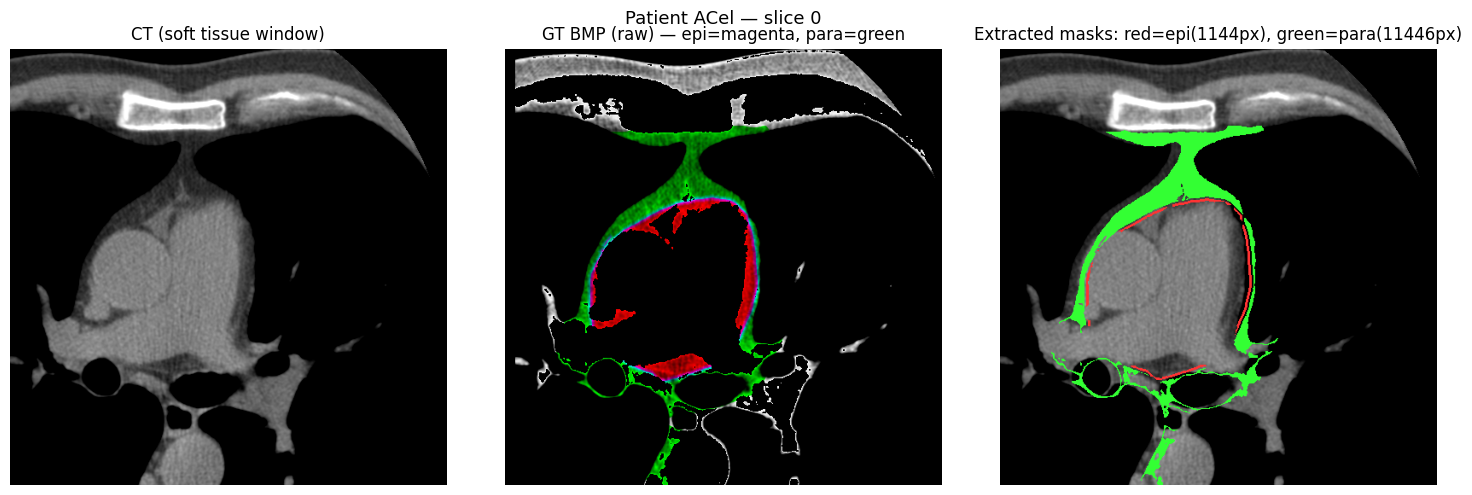

Saved fig01_annotation_overlay.png


In [ ]:


pat = patients[0]
dcm_files = sorted((DICOM_DIR / pat).glob("*.dcm"))
bmp_files = sorted((GT_FAT_DIR / pat).glob("*.bmp"))


for i, (dcm_f, bmp_f) in enumerate(zip(dcm_files, bmp_files)):
    arr = np.array(Image.open(bmp_f))
    epi_m, para_m = bmp_to_epi_para_masks(arr)
    if epi_m.any() and para_m.any():
        chosen_dcm, chosen_bmp, chosen_i = dcm_f, bmp_f, i
        break
else:
    chosen_dcm, chosen_bmp, chosen_i = dcm_files[len(dcm_files)//2], bmp_files[len(bmp_files)//2], len(dcm_files)//2

ds = pydicom.dcmread(chosen_dcm)
ct = dcm_to_hu(ds)
gt_arr = np.array(Image.open(chosen_bmp))
epi_mask_vis, para_mask_vis = bmp_to_epi_para_masks(gt_arr)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Patient {pat} — slice {chosen_i}", fontsize=13)


vmin, vmax = -200, 300
axes[0].imshow(ct, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("CT (soft tissue window)")
axes[0].axis("off")

axes[1].imshow(gt_arr)
axes[1].set_title(f"GT BMP (raw) — epi=magenta, para=green")
axes[1].axis("off")

ct_norm = np.clip((ct - vmin) / (vmax - vmin), 0, 1)
overlay = np.stack([ct_norm, ct_norm, ct_norm], axis=-1)
overlay[epi_mask_vis] = [1.0, 0.2, 0.2] 
overlay[para_mask_vis] = [0.2, 1.0, 0.2] 
axes[2].imshow(overlay)
axes[2].set_title(f"Extracted masks: red=epi({epi_mask_vis.sum()}px), green=para({para_mask_vis.sum()}px)")
axes[2].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig01_annotation_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig01_annotation_overlay.png")

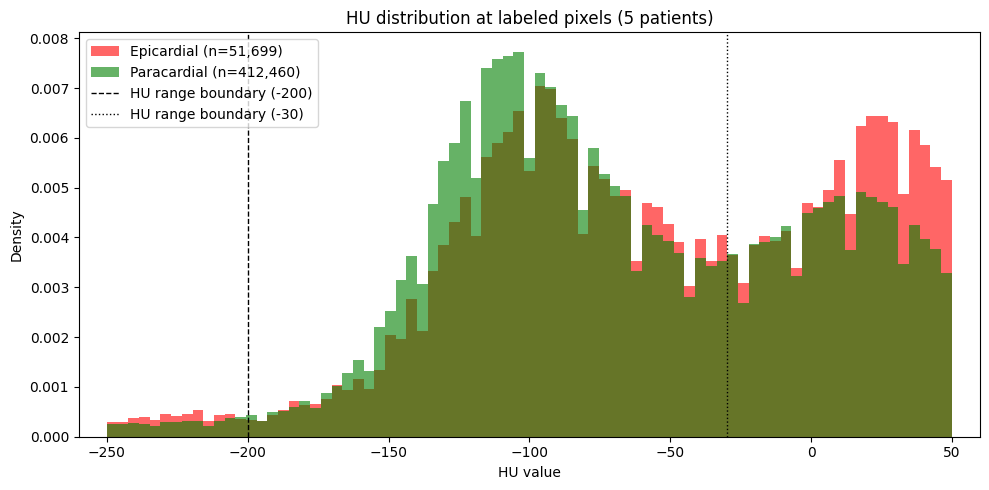

Saved fig02_hu_distributions.png


In [ ]:

if hu_results:
    fig, ax = plt.subplots(figsize=(10, 5))
    bins = np.linspace(-250, 50, 80)
    all_epi = np.concatenate([v["epi"] for v in hu_results.values()])
    all_para = np.concatenate([v["para"] for v in hu_results.values()])
    ax.hist(all_epi[np.isfinite(all_epi)], bins=bins, alpha=0.6, color="red", label=f"Epicardial (n={len(all_epi):,})", density=True)
    ax.hist(all_para[np.isfinite(all_para)], bins=bins, alpha=0.6, color="green", label=f"Paracardial (n={len(all_para):,})", density=True)
    ax.axvline(-200, color="k", linestyle="--", linewidth=1, label="HU range boundary (-200)")
    ax.axvline(-30, color="k", linestyle=":", linewidth=1, label="HU range boundary (-30)")
    ax.set_xlabel("HU value")
    ax.set_ylabel("Density")
    ax.set_title("HU distribution at labeled pixels (5 patients)")
    ax.legend()
    ax.set_xlim(-260, 60)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "fig02_hu_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved fig02_hu_distributions.png")

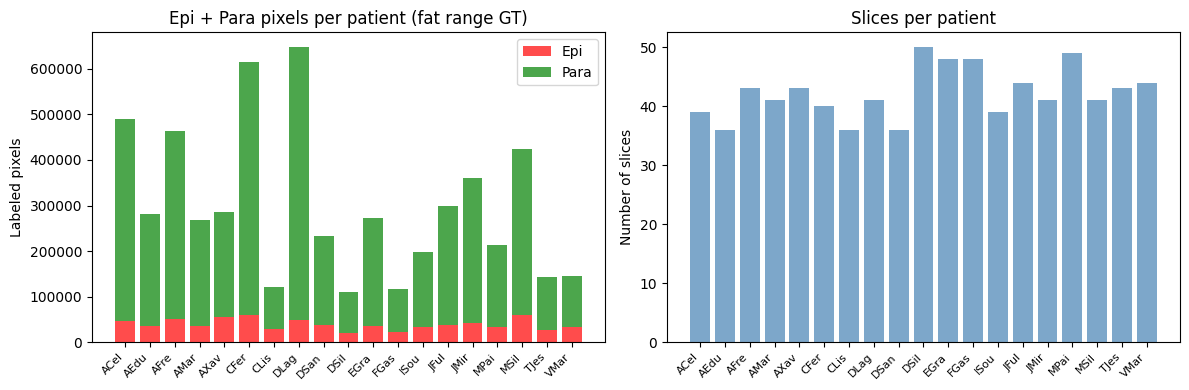

Saved fig03_per_patient_stats.png


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = range(len(df))
axes[0].bar(x, df["epi_pixels"], color="red", alpha=0.7, label="Epi")
axes[0].bar(x, df["para_pixels"], bottom=df["epi_pixels"], color="green", alpha=0.7, label="Para")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(df["patient"], rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Labeled pixels")
axes[0].set_title("Epi + Para pixels per patient (fat range GT)")
axes[0].legend()

axes[1].bar(x, df["num_slices"], color="steelblue", alpha=0.7)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(df["patient"], rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Number of slices")
axes[1].set_title("Slices per patient")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig03_per_patient_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig03_per_patient_stats.png")

## Evaluation

In [ ]:

overlap_ok = df["both_pixels"].sum() == 0
total_epi = df["epi_pixels"].sum()
total_para = df["para_pixels"].sum()

if hu_results:
    all_epi_hu = np.concatenate([v["epi"] for v in hu_results.values()])
    all_para_hu = np.concatenate([v["para"] for v in hu_results.values()])
    epi_in_range = ((all_epi_hu >= -200) & (all_epi_hu <= -30)).mean()
    para_in_range = ((all_para_hu >= -200) & (all_para_hu <= -30)).mean()
else:
    epi_in_range = para_in_range = float("nan")

results = {
    "num_patients": int(len(df)),
    "slices_per_patient_min": int(df["num_slices"].min()),
    "slices_per_patient_max": int(df["num_slices"].max()),
    "slices_per_patient_mean": float(df["num_slices"].mean()),
    "total_epi_pixels": int(total_epi),
    "total_para_pixels": int(total_para),
    "epi_para_overlap_pixels": int(df["both_pixels"].sum()),
    "epi_para_exclusive": bool(overlap_ok),
    "epi_fraction_of_fat": float(total_epi / (total_epi + total_para)) if (total_epi + total_para) > 0 else 0.0,
    "epi_hu_in_fat_range_frac": float(epi_in_range) if not np.isnan(epi_in_range) else None,
    "para_hu_in_fat_range_frac": float(para_in_range) if not np.isnan(para_in_range) else None,
    "color_encoding": "R=epi, G=para (hypothesis to verify from above)",
}

with open(METRICS_PATH, "w") as f:
    json.dump(results, f, indent=2)

print("=== Key findings ===")
for k, v in results.items():
    print(f"  {k}: {v}")

=== Key findings ===
  num_patients: 19
  slices_per_patient_min: 36
  slices_per_patient_max: 50
  slices_per_patient_mean: 42.21052631578947
  total_epi_pixels: 747245
  total_para_pixels: 4950390
  epi_para_overlap_pixels: 0
  epi_para_exclusive: True
  epi_fraction_of_fat: 0.13115002979306326
  epi_hu_in_fat_range_frac: 0.4271069072902764
  para_hu_in_fat_range_frac: 0.4530984822770693
  color_encoding: R=epi, G=para (hypothesis to verify from above)
